# Extracting CellProfiler Features from Synthetic Cell Images

This notebook shows the core `cellgenerator` workflow in three steps:

1. **Generate** a synthetic cell image with a known shape and staining pattern
2. **Extract** CellProfiler morphological features from it
3. **Inspect** the resulting feature table

> **Prerequisites**  
> All steps require only `pip install cellgenerator` — no CellProfiler installation or conda environment needed.  
> See the [feature naming guide](../setup/cellprofiler) for differences between cp_measure and CellProfiler column names.

In [1]:
import matplotlib.pyplot as plt

from cellgenerator import Image
from cellgenerator.mask import EllipseMask
from cellgenerator.measure import CellProfilerMeasurer
from cellgenerator.stain import SpatialStain

## Step 1 - Generate a synthetic cell

A `cellgenerator` image is composed of two parts:

| Part | What it controls |
|------|------------------|
| **Mask** | The cell outline (shape) |
| **Stain** | The intensity pattern inside the cell |

Here we create an elliptical cell with a spatially varying stain.

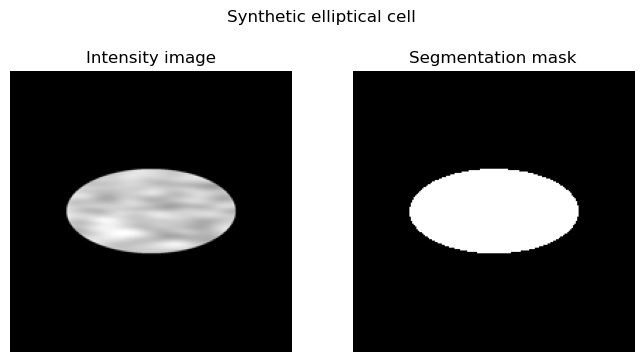

In [2]:
# Build the cell at high internal resolution; render size is set later
cell = Image(
    dim=(1000, 1000),
    mask=EllipseMask(y_radius=150, x_radius=300),
    stain=SpatialStain(y_corr=10, x_corr=40),
)

OUT = (200, 200)  # pixel size used for rendering and measurement

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))
axes[0].imshow(cell.get_img(OUT), cmap="gray")
axes[0].set_title("Intensity image")
axes[0].axis("off")
axes[1].imshow(cell.get_mask_img(OUT), cmap="gray")
axes[1].set_title("Segmentation mask")
axes[1].axis("off")
fig.suptitle("Synthetic elliptical cell", y=1.02)
plt.tight_layout()
plt.show()

## Step 2 - Extract CellProfiler features

`CellProfilerMeasurer` uses [cp_measure](https://github.com/afermg/cp_measure)
to extract CellProfiler-compatible morphological features and returns them as a
tidy `pandas.DataFrame`. Feature groups extracted:

| Group | Example features |
|-------|------------------|
| Size & shape | `Area`, `Eccentricity`, `Solidity`, Zernike moments |
| Intensity | `Intensity_MeanIntensity`, `Intensity_IntegratedIntensity` |
| Texture | `AngularSecondMoment_3_00_256`, `Entropy_5_00_256` (Haralick) |
| Granularity | `Granularity_1`, `Granularity_2`, … |
| Radial distribution | `RadialDistribution_FracAtD_1of4`, … |


In [3]:
measurer = CellProfilerMeasurer()
CELLPROFILER_AVAILABLE = True

In [4]:
df = measurer.measure(cell, dim=OUT)
print(f"Features extracted: {df.shape[1]}")

Features extracted: 373


## Step 3 - Inspect the feature table

Each call to `measure()` returns a single-row `DataFrame` - one column per CellProfiler feature.

In [5]:
# One representative feature per group
picks = [
    next((c for c in df.columns if c == "Area"), None),
    next((c for c in df.columns if c == "Eccentricity"), None),
    next((c for c in df.columns if c == "Intensity_MeanIntensity"), None),
    next((c for c in df.columns if c == "Intensity_IntegratedIntensity"), None),
    next((c for c in df.columns if "AngularSecondMoment" in c), None),
    next((c for c in df.columns if c.startswith("Granularity_")), None),
    next((c for c in df.columns if c.startswith("RadialDistribution_")), None),
]
picks = [c for c in picks if c]
display(df[picks].T.rename(columns={0: "value"}))

In [6]:
groups = {
    "Size & shape": [
        c
        for c in df.columns
        if not c.startswith(("Intensity", "Granularity", "Radial", "Zernike"))
    ],
    "Intensity": [c for c in df.columns if c.startswith("Intensity_")],
    "Texture": [
        c
        for c in df.columns
        if any(
            h in c
            for h in [
                "AngularSecond",
                "Contrast",
                "Correlation",
                "Variance",
                "InverseDiff",
                "SumA",
                "SumV",
                "SumE",
                "Entropy",
                "DiffV",
                "DiffE",
                "InfoMeas",
            ]
        )
    ],
    "Granularity": [c for c in df.columns if c.startswith("Granularity_")],
    "RadialDist": [c for c in df.columns if c.startswith("RadialDistribution_")],
}
print(f"Total features: {df.shape[1]}")
print("Features per group:")
for name, cols in groups.items():
    print(f"  {name:<22} {len(cols):>4}")